In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [3]:
from keras.datasets import fashion_mnist

In [4]:
from keras import Sequential

In [5]:
from keras.layers import Flatten,Dense,Conv2D,MaxPooling2D,Dropout

In [6]:
from keras.optimizers import Adam

In [7]:
from keras.losses import SparseCategoricalCrossentropy

In [8]:
data=fashion_mnist.load_data()

In [9]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
x_train.shape

(60000, 28, 28)

In [10]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

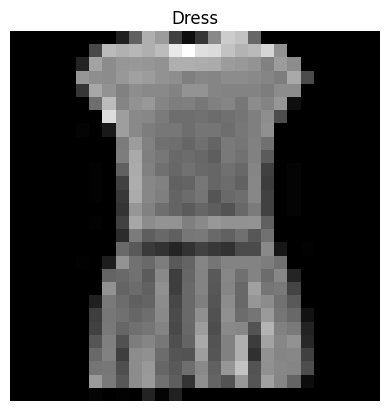

In [11]:
plt.imshow(x_train[3],cmap='gray')
plt.title(class_names[y_train[3]])
plt.axis('off')
plt.show()

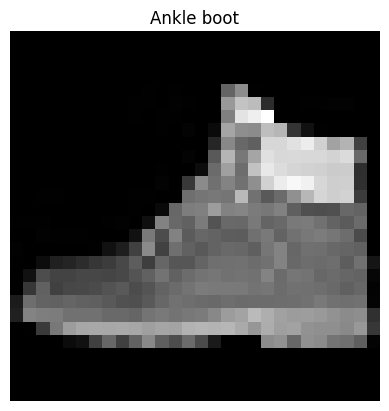

In [12]:
plt.imshow(x_train[90],cmap='gray')
plt.title(class_names[y_train[90]])
plt.axis('off')
plt.show()

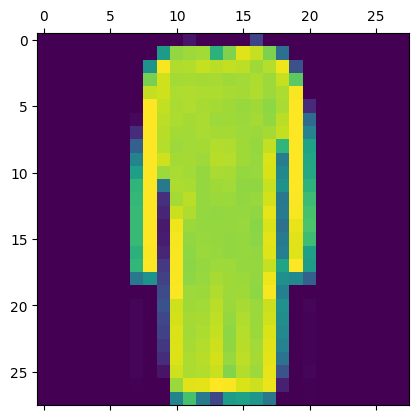

In [13]:
plt.matshow(x_train[25])

In [14]:
x_train=x_train.reshape((x_train.shape[0],x_train.shape[1],x_train.shape[2],1))

x_test=x_test.reshape((x_test.shape[0],x_test.shape[1],x_test.shape[2],1))


In [15]:
x_train.shape

(60000, 28, 28, 1)

In [16]:
x_test.shape

(10000, 28, 28, 1)

In [17]:
model=Sequential()
model.add(Conv2D(32,(3,3),input_shape=(28,28,1),strides=(2,2),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer=Adam(),
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

In [19]:
model.fit(x_train,y_train,epochs=5,batch_size=1000,validation_split=0.2)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.2007 - loss: 3.8491 - val_accuracy: 0.3716 - val_loss: 1.6917
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.4676 - loss: 1.5096 - val_accuracy: 0.6479 - val_loss: 0.9837
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6356 - loss: 1.0038 - val_accuracy: 0.7207 - val_loss: 0.7587
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6927 - loss: 0.8193 - val_accuracy: 0.7463 - val_loss: 0.6812
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7230 - loss: 0.7353 - val_accuracy: 0.7602 - val_loss: 0.6251


In [20]:
loss,accuracy=model.evaluate(x_test,y_test)
print('test_accuracy:',accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7542 - loss: 0.6346
test_accuracy: 0.7541999816894531


In [21]:
import numpy as np
pred=model.predict(x_test[:1])
print('predicted:',np.argmax(pred))
print('actual:',y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
predicted: 9
actual: 9


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 14, 14, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 5, 5, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 85,184 (332.75 KB)

 Trainable params: 28,394 (110.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,790 (221.84 KB)